In [53]:
%reset -f
from sklearn.datasets import fetch_california_housing
import numpy as np
import copy
import torch
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import optuna
import plotly
torch.manual_seed(0)
np.random.seed(0)
torch.use_deterministic_algorithms(True) # problem with cuda

use_cuda=torch.cuda.is_available()
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
device = get_default_device()
device



device(type='cpu')

In [54]:
data = fetch_california_housing()
print(data.feature_names)
X, y = data.data, data.target

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [55]:
# train-test split of the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, shuffle=True)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

#X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device) # data to cuda

#kwargs = {'num_workers': 0, 'pin_memory': True} if use_cuda else {}
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(dataset = train_dataset, batch_size = 100, shuffle=False) # small batch size

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(dataset = test_dataset, batch_size = 100, shuffle=False) # small batch size

In [56]:
# Define the model
class NeuralNetwork(nn.Module):
    def __init__(self, num_layers = 3, num_nodes = 12):
        super().__init__()
        layers = []
        in_features = 8
        for i in range(num_layers):
            layers.append(torch.nn.Linear(in_features, num_nodes))
            layers.append(torch.nn.ReLU())
            in_features = num_nodes

        layers.append(torch.nn.Linear(num_nodes, 1))
        self.linear_relu_stack = torch.nn.Sequential(*layers)
#        self.linear_relu_stack = nn.Sequential(
#            nn.Linear(8, 24), # eight inputs
#            nn.ReLU(),
#            nn.Linear(24, 12),
#            nn.ReLU(),
#            nn.Linear(12, 6),
#            nn.ReLU(),
#            nn.Linear(6, 1) # one output
#        )
    
    def forward(self, x):
        output = self.linear_relu_stack(x)
        return output

model = NeuralNetwork(5,20).to(device=device) # model to cuda
print(model)

# loss function and optimizer
loss_fn = nn.MSELoss(reduction='sum')  # mean square error
optimizer = optim.Adam(model.parameters(), lr=0.01)

#X_batch, y_batch = next(iter(train_loader))
#X_batch = X_batch.to(device=device)
#model(X_batch).shape

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=8, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): ReLU()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): ReLU()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): ReLU()
    (10): Linear(in_features=20, out_features=1, bias=True)
  )
)


In [57]:
# training parameters
n_epochs = 10   # number of epochs to run

# training loop
for epoch in range(n_epochs):
    print(epoch)
    model.train() # tell pytorch you are training
    for X_batch, y_batch in train_loader:
        # forward pass
        X_batch, y_batch = X_batch.to(device=device), y_batch.to(device=device)
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        # backward pass
        optimizer.zero_grad()
        loss.backward()
        # update weights
        optimizer.step()

    # evaluate accuracy at end of each epoch
    model.eval() # tell pytorch you are testing
    mse = 0 
    for X_test, y_test in test_loader:
        X_test, y_test = X_test.to(device=device), y_test.to(device=device)
        y_pred = model(X_test)
        mse = loss_fn(y_pred, y_test)
        mse = mse + float(mse)
    mse = mse / len(test_dataset)
    #print(mse.data.item())
# restore model and return best accuracy
#model.load_state_dict(best_weights)

0
1
2
3
4
5
6
7
8
9


In [58]:
mse

tensor(0.0177, grad_fn=<DivBackward0>)

In [59]:
import optuna

def objective(trial): 
    num_layers = trial.suggest_int('num_layers', 1, 3)
    num_nodes = trial.suggest_int('num_nodes', 3, 10)
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    # write more tuning parameters here
    
    model = NeuralNetwork(num_layers,num_nodes).to(device=device) # model to cuda
    print(model)

    # loss function and optimizer
    loss_fn = nn.MSELoss(reduction='sum')  # mean square error
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # training parameters
    n_epochs = 10  # number of epochs to run

    # training loop
    for epoch in range(n_epochs):
        #print(epoch)
        model.train() # tell pytorch you are training
        for X_batch, y_batch in train_loader:
            # forward pass
            X_batch, y_batch = X_batch.to(device=device), y_batch.to(device=device)
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
    
        # evaluate accuracy at end of each epoch
        model.eval() # tell pytorch you are testing
        mse = 0 
        for X_test, y_test in test_loader:
            X_test, y_test = X_test.to(device=device), y_test.to(device=device)
            y_pred = model(X_test)
            mse = loss_fn(y_pred, y_test)
            mse = mse + float(mse)
        mse = mse / len(test_dataset)
        #print(mse.data.item())

        # which values to report
        trial.report(mse, epoch)
        # Handle pruning based on the intermediate value.
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return mse

In [60]:
from optuna.samplers import RandomSampler

study = optuna.create_study(direction='minimize', sampler=RandomSampler(seed=1))
study.optimize(objective, n_trials=5)

[I 2024-03-19 13:27:58,096] A new study created in memory with name: no-name-439f760c-70fa-42b8-bb0b-49cbc5a41e8b


NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)


[I 2024-03-19 13:28:00,725] Trial 0 finished with value: 5.092638969421387 and parameters: {'num_layers': 2, 'num_nodes': 8, 'lr': 1.0010539860510485e-05}. Best is trial 0 with value: 5.092638969421387.


NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=8, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=1, bias=True)
  )
)


[I 2024-03-19 13:28:03,061] Trial 1 finished with value: 1883.21923828125 and parameters: {'num_layers': 1, 'num_nodes': 4, 'lr': 2.3407464805767515e-05}. Best is trial 0 with value: 5.092638969421387.


...

[I 2024-03-19 13:28:05,391] Trial 2 finished with value: 0.39906659722328186 and parameters: {'num_layers': 1, 'num_nodes': 5, 'lr': 0.00038642916535526494}. Best is trial 2 with value: 0.39906659722328186.


NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=8, out_features=6, bias=True)
    (1): ReLU()
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): ReLU()
    (4): Linear(in_features=6, out_features=1, bias=True)
  )
)


[I 2024-03-19 13:28:07,963] Trial 3 finished with value: 0.021183043718338013 and parameters: {'num_layers': 2, 'num_nodes': 6, 'lr': 0.005506529897945991}. Best is trial 3 with value: 0.021183043718338013.


NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=8, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=1, bias=True)
  )
)


[I 2024-03-19 13:28:10,256] Trial 4 finished with value: 826.3110961914062 and parameters: {'num_layers': 1, 'num_nodes': 10, 'lr': 1.2869165107815022e-05}. Best is trial 3 with value: 0.021183043718338013.


In [62]:
study.best_trial.params
#{'num_layers': 2, 'num_nodes': 6, 'lr': 0.005506529897945991}



{'num_layers': 2, 'num_nodes': 6, 'lr': 0.005506529897945991}

In [ ]:
import plotly
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_param_importances
plot_optimization_history(study)

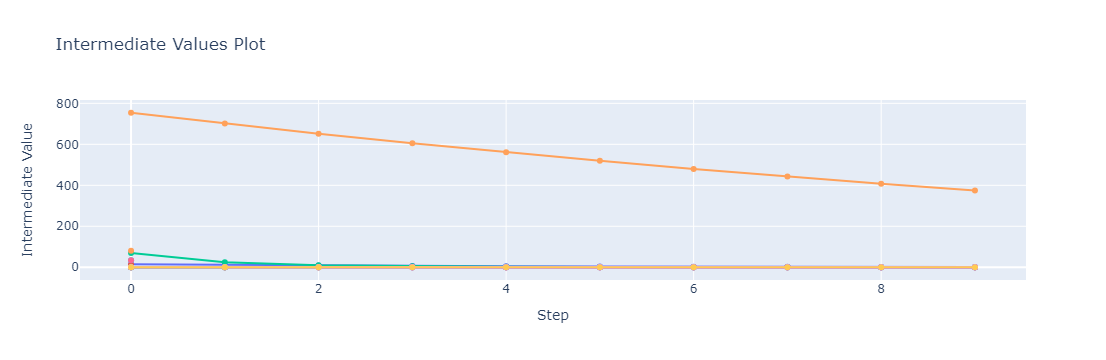

In [32]:
plot_intermediate_values(study)

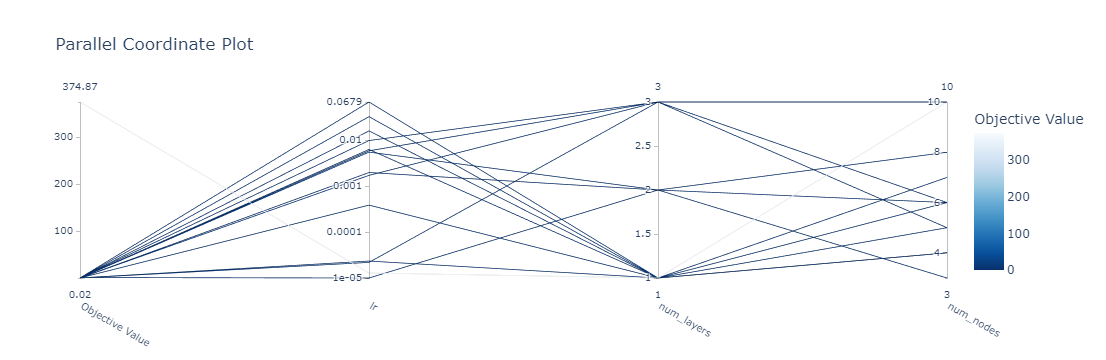

In [33]:
plot_parallel_coordinate(study)

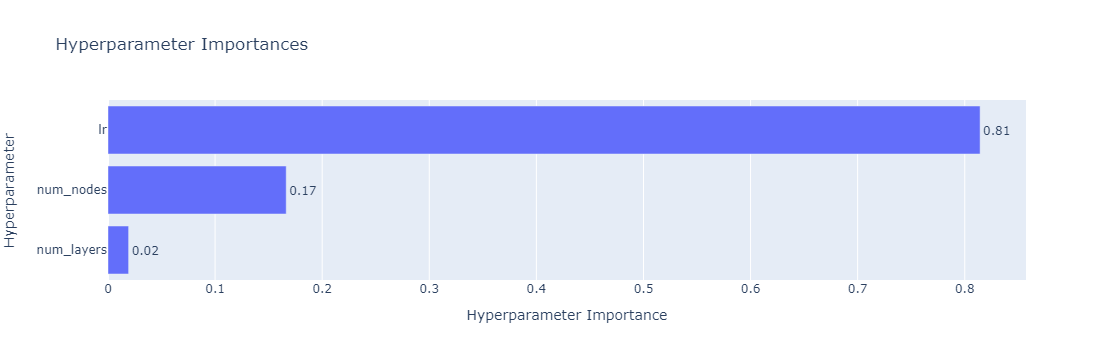

In [34]:
plot_param_importances(study)